# Các bản đồ

In [ ]:
import numpy as np

# np.savetxt('E:\last_dance\Last-dance\map\grid20_4.txt', grid20_4, fmt='%d')

# Kiểm tra nhanh:
# assert grid10.sum() == 20 and grid20.sum() == 80
# assert grid10[0,0] == 0 and grid10[-1,-1] == 0
# assert grid20[0,0] == 0 and grid20[-1,-1] == 0

In [ ]:
grid30 = np.loadtxt('E:\last_dance\Last-dance\map\grid30.txt', dtype=np.int8)

goals = [(4, 6), (4, 15), (16, 4), (12, 14), (20, 20), (20, 14), (23, 17), (17, 15)]
for goal in goals:
    grid30[goal] = 2

grid = grid30
n = grid.shape[0]

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 1 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 1 1 1 0 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0]
 [0 0 1 1 1 1 2 0 1 1 1 1 0 0 0 2 0 0 0 0 0 0 0 1 1 1 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
 [1 1 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1]
 [1 1 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 1 1 1 1 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1 0 0 1 1 1 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 0]
 [0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 1 1 0 0 0 1 0 0 1 1 1 1 1 0 0 1 0 0 0 0 0

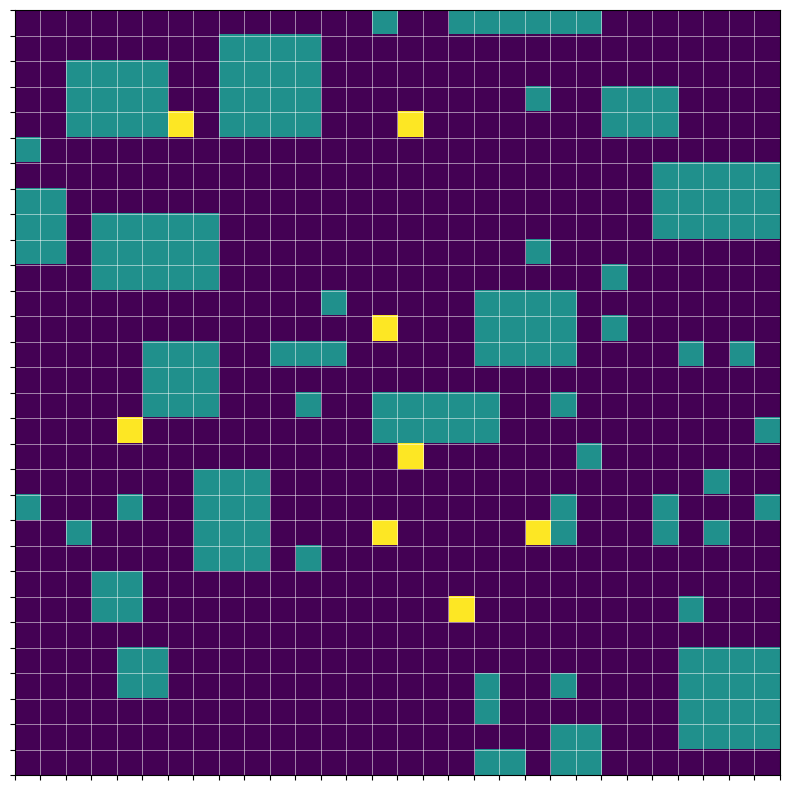

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Trực quan hóa đường đi Q-Learning
fig, ax = plt.subplots(figsize=(8, 8))

# Vẽ bản đồ (0=free, 1=obstacle)
# Sử dụng origin="upper" để đặt (0,0) ở góc trên bên trái
im = ax.imshow(grid, origin="upper", interpolation="nearest", cmap="viridis")

# ======= THÊM LƯỚI Ô NGUYÊN  =======
n, m = grid.shape
ax.set_xlim(-0.5, m - 0.5) # Điều chỉnh giới hạn dựa trên lưới không xoay
ax.set_ylim(n - 0.5, -0.5) # Điều chỉnh giới hạn và đảo ngược cho origin="upper"
ax.set_aspect('equal')
ax.set_xticks(np.arange(-0.5, m, 1), minor=False) # Điều chỉnh vạch đánh dấu
ax.set_yticks(np.arange(-0.5, n, 1), minor=False) # Điều chỉnh vạch đánh dấu
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6, color='white')


plt.tight_layout()
# out_path_q = "/mnt/data/q_learning_path.png"
# plt.savefig(out_path_q, dpi=180)
plt.show() # Hiển thị biểu đồ đường đi Q-Learning
# plt.close(fig)
# print("\nĐã lưu trực quan hóa đường đi Q-Learning vào:", out_path_q)


In [7]:
import time
import numpy as np
import math
import heapq # Import the heapq module for priority queue

In [8]:
# test heapq
pq = []
heapq.heappush(pq, (5, "task1"))
heapq.heappush(pq, (3, "task2"))
heapq.heappush(pq, (4, "task3"))
print(pq)
print(heapq.heappop(pq)) # Output: (3, "task2")
print(heapq.heappop(pq)) # Output: (4, "task3")
print(heapq.heappop(pq)) # Output: (5, "task1")

[(3, 'task2'), (5, 'task1'), (4, 'task3')]
(3, 'task2')
(4, 'task3')
(5, 'task1')


In [9]:
# Kiểm tra điểm có nằm trong lưới không
def in_bounds(p, n, m):
    return 0 <= p[0] < n and 0 <= p[1] < m

# ---------- helpers ----------
MOVES8 = [(-1,-1), (-1,0), (-1,1),
          ( 0,-1),          ( 0,1),
          ( 1,-1), ( 1,0),  ( 1,1)]

# Hàm khoảng cách Euclid giữa hai điểm
def euclid(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1]) # math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

# Tính độ dài đường đi
def path_length(path):
    if not path or len(path) < 2:
        return 0.0
    return sum(euclid(path[i], path[i + 1]) for i in range(len(path) - 1))

In [10]:
# Hàm tìm đường đi ngắn nhất giữa hai điểm (start_point) và (end_point) sử dụng Dijkstra
# Với khả năng di chuyển 8 hướng và tránh chướng ngại vật (giá trị 1)
# Độ phức tạp: O(n*m*log(n*m)) trong trường hợp xấu nhất, với n và m là số hàng và số cột của lưới
def dijkstra(grid_map, start_point, end_point):
    n_rows, n_cols = grid_map.shape

    # Kiểm tra điểm bắt đầu và kết thúc có hợp lệ không
    if not in_bounds(start_point, n_rows, n_cols) or grid_map[start_point[0]][start_point[1]] == 1:
        print(f"Điểm bắt đầu {start_point} không hợp lệ hoặc là chướng ngại vật.")
        return [], 1e10 # Trả về đường đi rỗng và độ dài vô cùng lớn nếu điểm bắt đầu không hợp lệ
    if not in_bounds(end_point, n_rows, n_cols) or grid_map[end_point[0]][end_point[1]] == 1:
        print(f"Điểm kết thúc {end_point} không hợp lệ hoặc là chướng ngại vật.")
        return [], 1e10

    # distances lưu trữ khoảng cách ngắn nhất từ start_point đến mỗi ô
    # dictionary (row, col) -> min distance giữa start_point và (row, col), kích thước n_rows x n_cols
    distances = { (r, c): 1e10 for r in range(n_rows) for c in range(n_cols) } 
    distances[start_point] = 0

    # predecessors lưu trữ ô trước đó trong đường đi ngắn nhất, dạng dictionary (row, col) -> (prev_row, prev_col)
    predecessors = {}

    # priority_queue (min-heap) để lưu trữ (khoảng_cách, ô_hiện_tại), trong đó khoảng cách là khoảng cách ngắn nhất đã biết từ start_point đến ô_hiện_tại
    priority_queue = [ (0, start_point) ]

    while priority_queue: # Trong khi hàng đợi ưu tiên không rỗng
        current_distance, current_node = heapq.heappop(priority_queue) # Lấy ô có khoảng cách nhỏ nhất từ hàng đợi
        # print(f"Đang xử lý node {current_node} với khoảng cách {current_distance}")
        # print(f"Hàng đợi ưu tiên: {priority_queue}")

        # Nếu đã tìm thấy đường đi ngắn nhất đến current_node rồi, bỏ qua
        if current_distance > distances[current_node]:
            continue

        # Nếu đã đến đích, dừng tìm kiếm
        if current_node == end_point:
            break

        # Duyệt qua 8 ô lân cận
        for dr, dc in MOVES8:
            neighbor_node = (current_node[0] + dr, current_node[1] + dc)

            # Kiểm tra ô lân cận có hợp lệ không (trong biên, không phải chướng ngại vật)
            if in_bounds(neighbor_node, n_rows, n_cols) and grid_map[neighbor_node[0]][neighbor_node[1]] != 1:
                # Tính chi phí di chuyển (1 cho ngang/dọc, sqrt(2) cho chéo)
                move_cost = math.hypot(dr, dc) # math.hypot((dr, dc)) will be 1 or sqrt(2)

                # Tính khoảng cách mới đến ô lân cận
                new_distance = current_distance + move_cost

                # Nếu tìm thấy đường đi ngắn hơn đến ô lân cận
                if new_distance < distances[neighbor_node]:
                    distances[neighbor_node] = new_distance
                    # print(distances)
                    predecessors[neighbor_node] = current_node
                    # print(predecessors)
                    heapq.heappush(priority_queue, (new_distance, neighbor_node))

    # Tái tạo đường đi từ end_point về start_point
    path = []
    if distances[end_point] == 1e10: # Không tìm thấy đường đi
        return [], 1e10

    current = end_point
    while current != start_point:
        path.append(current)
        current = predecessors.get(current)
        if current is None: # Lỗi: không thể truy vết về điểm bắt đầu
            return [], 1e10
    path.append(start_point)
    path.reverse()

    return path, distances[end_point]

In [11]:
# # test Dijkstra
# test_grid = np.array([
#     [0, 0, 0, 1, 0],
#     [0, 1, 0, 1, 0],
#     [0, 0, 0, 0, 0],
#     [1, 1, 1, 1, 0],
#     [0, 0, 0, 1, 0]
# ], dtype=np.int8)
# start = (0, 0)
# end = (4, 4)
# path, length = dijkstra(test_grid, start, end)
# print("Đường đi ngắn nhất:", path)
# print("Độ dài đường đi:", length)

In [12]:
import matplotlib.pyplot as plt
import numpy as np
def visualize_path(grid, path, mandatory_waypoints):
    if path:
        print("\nĐường đi được trích xuất từ bảng Q:")
        print(path)
        L_q = path_length(path)
        print("Độ dài đường đi:", round(L_q, 3))

        # Trực quan hóa đường đi Q-Learning
        print("\nĐang trực quan hóa đường đi Q-Learning...")
        fig, ax = plt.subplots(figsize=(8, 8))

        # Vẽ bản đồ (0=free, 1=obstacle)
        # Sử dụng origin="upper" để đặt (0,0) ở góc trên bên trái
        im = ax.imshow(grid, origin="upper", interpolation="nearest", cmap="viridis")

        # Vẽ đường đi theo từng bước
        xs = [p[1] for p in path] # Hoán đổi x và y để vẽ
        ys = [p[0] for p in path] # Hoán đổi x và y để vẽ
        ax.plot(xs, ys, linewidth=2, color="red", zorder=3) # Sử dụng màu khác cho đường đi Q
        ax.scatter([path[0][1], path[-1][1]], # Hoán đổi x và y để vẽ
                [path[0][0], path[-1][0]], # Hoán đổi x và y để vẽ
                marker='x', s=160, linewidths=2.5, color="red", zorder=4)

        # Vẽ các điểm bắt buộc
        mandatory_wp_x = [wp[1] for wp in mandatory_waypoints]
        mandatory_wp_y = [wp[0] for wp in mandatory_waypoints]
        ax.scatter(mandatory_wp_x, mandatory_wp_y, marker='o', s=100, linewidths=2.5, color="blue", zorder=5, label="Điểm bắt buộc")

        # ======= THÊM LƯỚI Ô NGUYÊN  =======
        n, m = grid.shape
        ax.set_xlim(-0.5, m - 0.5) # Điều chỉnh giới hạn dựa trên lưới không xoay
        ax.set_ylim(n - 0.5, -0.5) # Điều chỉnh giới hạn và đảo ngược cho origin="upper"
        ax.set_aspect('equal')
        ax.set_xticks(np.arange(-0.5, m, 1), minor=False) # Điều chỉnh vạch đánh dấu
        ax.set_yticks(np.arange(-0.5, n, 1), minor=False) # Điều chỉnh vạch đánh dấu
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.6, color='white')

        ax.set_title(f"Đường đi có độ dài={L_q:.2f}, số bước={len(path)-1}")
        ax.legend()

        plt.tight_layout()
        # out_path_q = "/mnt/data/q_learning_path.png"
        # plt.savefig(out_path_q, dpi=180)
        plt.show() # Hiển thị biểu đồ đường đi Q-Learning
        # plt.close(fig)
        # print("\nĐã lưu trực quan hóa đường đi Q-Learning vào:", out_path_q)

    else:
        print("\nKhông thể trích xuất đường đi hợp lệ từ bảng Q.")

In [13]:
# Hàm chính để tìm đường đi ngắn nhất qua các điểm bắt buộc
def find_shortest_path_with_mandatory_waypoints_1(grid_map, start_node, end_node, mandatory_waypoints):

    # Các điểm bắt buộc (giá trị 2) trên bản đồ không được là chướng ngại vật (giá trị 1)
    # Nếu một điểm bắt buộc là chướng ngại vật, nó sẽ được bỏ qua
    valid_mandatory_waypoints = []
    for wp in mandatory_waypoints:
        if grid_map[wp[0]][wp[1]] != 1:
            valid_mandatory_waypoints.append(wp)
        else:
            print(f"Cảnh báo: Điểm bắt buộc {wp} là chướng ngại vật và sẽ bị bỏ qua.")

    # Sắp xếp các điểm bắt buộc để đảm bảo tính nhất quán (không đảm bảo tối ưu toàn cục cho TSP)
    # Đây là cách tiếp cận đơn giản nhất khi các điểm phải được thăm theo một thứ tự cụ thể.
    # Để tối ưu thứ tự các điểm bắt buộc, cần một thuật toán giải quyết bài toán người du lịch (TSP).
    # sắp xếp theo thứ tự hàng dọc, sau đó hàng ngang (có thể thay đổi tùy theo yêu cầu cụ thể)
    sorted_waypoints = sorted(valid_mandatory_waypoints)

    # Tạo danh sách tất cả các điểm cần đi qua theo thứ tự: Start -> Waypoints (sắp xếp) -> End
    all_points = [start_node] + sorted_waypoints + [end_node]

    total_path = []
    total_length = 0.0

    # Duyệt qua từng đoạn đường giữa các điểm liên tiếp
    for i in range(len(all_points) - 1):
        segment_start = all_points[i]
        segment_end = all_points[i+1]

        print(f"Đang tìm đường đi từ {segment_start} đến {segment_end}...")
        # Sử dụng thuật toán Dijkstra tổng quát thay vì find_path_segment_down_right
        current_segment_path, current_segment_length = dijkstra(grid_map, segment_start, segment_end)

        if current_segment_length > 1e9: # Nếu không tìm thấy đường đi cho một đoạn
            print(f"Không tìm thấy đường đi hợp lệ từ {segment_start} đến {segment_end}. Toàn bộ đường đi không khả dụng.")
            return [], 1e10 # Trả về lỗi nếu bất kỳ đoạn nào không tìm thấy

        # Nối đoạn đường hiện tại vào tổng đường đi
        # Tránh lặp lại điểm cuối của đoạn trước (điểm bắt đầu của đoạn hiện tại)
        if i > 0:
            total_path.extend(current_segment_path[1:])
        else:
            total_path.extend(current_segment_path)

        total_length += current_segment_length

    return total_path, total_length

In [14]:
valid_mandatory_waypoints = [(4, 6), (4, 15), (16, 4), (12, 14), (20, 20), (20, 14), (23, 17), (17, 15)]
sorted_waypoints = sorted(valid_mandatory_waypoints)
print("Điểm bắt buộc hợp lệ sau khi loại bỏ chướng ngại vật:", sorted_waypoints)

Điểm bắt buộc hợp lệ sau khi loại bỏ chướng ngại vật: [(4, 6), (4, 15), (12, 14), (16, 4), (17, 15), (20, 14), (20, 20), (23, 17)]


In [15]:
# --- Thực thi chính ---
start_exec_time = time.time()

start_node = (0, 0)
end_node = (n-1, n-1)

# Trích xuất các điểm bắt buộc (giá trị 2) từ bản đồ
mandatory_waypoints = []
for r in range(n):
    for c in range(n):
        if grid[r][c] == 2:
            mandatory_waypoints.append((r, c))

print(f"Các điểm bắt buộc phải đi qua được tìm thấy: {mandatory_waypoints}")
if not mandatory_waypoints:
    print("Không có điểm bắt buộc nào (số 2) trên bản đồ. Giải thuật sẽ tìm đường đi từ (0,0) đến (n-1,n-1) bình thường.")
    # Fallback to original single-segment path if no waypoints
    path, L_q = dijkstra(grid, start_node, end_node)
else:
    path, L_q = find_shortest_path_with_mandatory_waypoints_1(grid, start_node, end_node, mandatory_waypoints)

end_exec_time = time.time()

def extract_goal_order(path, goals):
    seen = set()
    order = []
    for p in path:
        if p in goals and p not in seen:
            order.append(p)
            seen.add(p)
    return order

if L_q > 1e9:
    print("Không tìm thấy đường đi hợp lệ bao gồm tất cả các điểm bắt buộc.")
else:
    print(f"\nĐộ dài đường đi ngắn nhất qua tất cả các điểm bắt buộc: {L_q:.2f}")
    print("Đường đi (theo thứ tự):")
    # For very long paths, printing all might be excessive, but for 30x30, it's ok.
    # for cell in path:
    #     print(cell)
goal_order = extract_goal_order(path, goals)
print("Thu tu goal:", goal_order)

print(f"Thời gian chạy: {end_exec_time - start_exec_time:.6f} giây")

Các điểm bắt buộc phải đi qua được tìm thấy: [(4, 6), (4, 15), (12, 14), (16, 4), (17, 15), (20, 14), (20, 20), (23, 17)]
Đang tìm đường đi từ (0, 0) đến (4, 6)...
Đang tìm đường đi từ (4, 6) đến (4, 15)...
Đang tìm đường đi từ (4, 15) đến (12, 14)...
Đang tìm đường đi từ (12, 14) đến (16, 4)...
Đang tìm đường đi từ (16, 4) đến (17, 15)...
Đang tìm đường đi từ (17, 15) đến (20, 14)...
Đang tìm đường đi từ (20, 14) đến (20, 20)...
Đang tìm đường đi từ (20, 20) đến (23, 17)...
Đang tìm đường đi từ (23, 17) đến (29, 29)...

Độ dài đường đi ngắn nhất qua tất cả các điểm bắt buộc: 78.28
Đường đi (theo thứ tự):
Thu tu goal: [(4, 6), (4, 15), (12, 14), (16, 4), (17, 15), (20, 14), (20, 20), (23, 17)]
Thời gian chạy: 0.006703 giây



Đường đi được trích xuất từ bảng Q:
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 5), (2, 6), (3, 6), (4, 6), (4, 7), (5, 8), (5, 9), (5, 10), (5, 11), (5, 12), (5, 13), (4, 14), (4, 15), (5, 15), (6, 15), (7, 15), (8, 15), (9, 15), (10, 15), (11, 15), (12, 14), (13, 13), (14, 12), (14, 11), (14, 10), (14, 9), (15, 8), (16, 7), (16, 6), (16, 5), (16, 4), (16, 5), (16, 6), (16, 7), (16, 8), (16, 9), (16, 10), (16, 11), (16, 12), (16, 13), (17, 14), (17, 15), (18, 15), (19, 15), (20, 14), (20, 15), (20, 16), (20, 17), (20, 18), (20, 19), (20, 20), (21, 19), (22, 18), (23, 17), (23, 18), (23, 19), (23, 20), (24, 21), (25, 22), (26, 23), (27, 24), (28, 25), (29, 26), (29, 27), (29, 28), (29, 29)]
Độ dài đường đi: 78.284

Đang trực quan hóa đường đi Q-Learning...


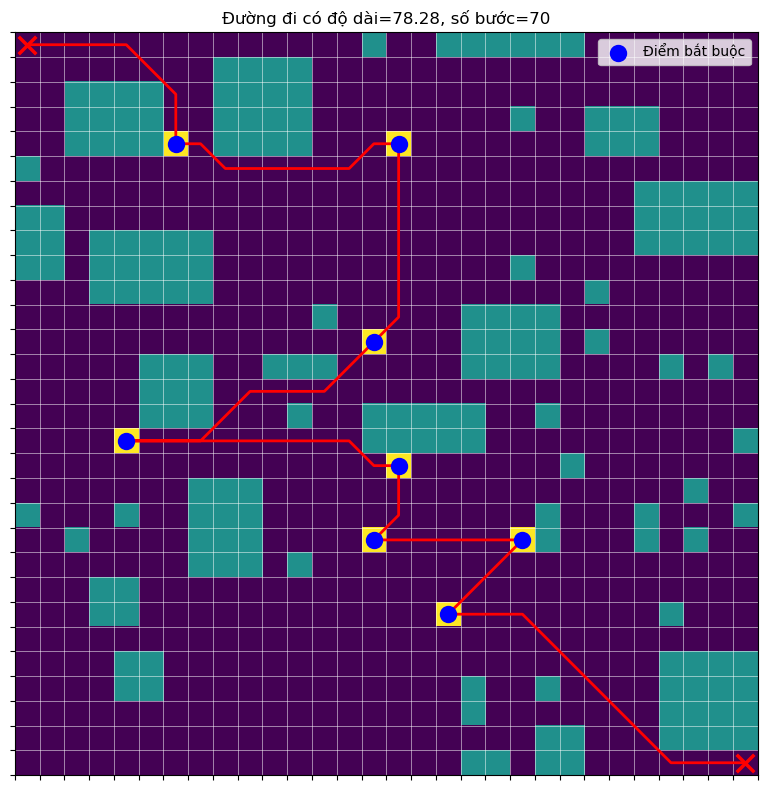

In [16]:
visualize_path(grid, path, mandatory_waypoints)

In [17]:
# Hàm chính để tìm đường đi ngắn nhất qua các điểm bắt buộc
def find_shortest_path_with_mandatory_waypoints_2(grid_map, start_node, end_node, mandatory_waypoints):
    n_rows, n_cols = grid_map.shape

    # Lọc ra các điểm bắt buộc hợp lệ (không phải chướng ngại vật)
    valid_mandatory_waypoints = set()
    for wp in mandatory_waypoints:
        if in_bounds(wp, n_rows, n_cols) and grid_map[wp[0]][wp[1]] != 1:
            valid_mandatory_waypoints.add(wp)
        else:
            print(f"Cảnh báo: Điểm bắt buộc {wp} không hợp lệ hoặc là chướng ngại vật và sẽ bị bỏ qua.")

    all_points = [start_node]
    current_point = start_node
    unvisited_waypoints = set(valid_mandatory_waypoints)

    while unvisited_waypoints:
        nearest_waypoint = None
        min_dist_to_waypoint = float('inf')

        # Tìm điểm bắt buộc gần nhất với current_point trong số các điểm chưa được thăm
        for wp in unvisited_waypoints:
            # Use Euclidean distance for simplicity in greedy choice, not pathfinding cost
            dist = euclid(current_point, wp)
            if dist < min_dist_to_waypoint:
                min_dist_to_waypoint = dist
                nearest_waypoint = wp

        if nearest_waypoint is None: # Should not happen if unvisited_waypoints is not empty
            break

        # Thêm điểm gần nhất vào danh sách và cập nhật current_point
        all_points.append(nearest_waypoint)
        unvisited_waypoints.remove(nearest_waypoint)
        current_point = nearest_waypoint

    all_points.append(end_node)

    total_path = []
    total_length = 0.0

    # Duyệt qua từng đoạn đường giữa các điểm liên tiếp
    for i in range(len(all_points) - 1):
        segment_start = all_points[i]
        segment_end = all_points[i+1]

        print(f"Đang tìm đường đi từ {segment_start} đến {segment_end}...")
        current_segment_path, current_segment_length = dijkstra(grid_map, segment_start, segment_end)

        if current_segment_length > 1e9: # Nếu không tìm thấy đường đi cho một đoạn
            print(f"Không tìm thấy đường đi hợp lệ từ {segment_start} đến {segment_end}. Toàn bộ đường đi không khả dụng.")
            return [], 1e10 # Trả về lỗi nếu bất kỳ đoạn nào không tìm thấy

        # Nối đoạn đường hiện tại vào tổng đường đi
        if i > 0:
            total_path.extend(current_segment_path[1:])
        else:
            total_path.extend(current_segment_path)

        total_length += current_segment_length

    return total_path, total_length

# --- Thực thi chính ---
start_exec_time = time.time()

start_node = (0, 0)
end_node = (n-1, n-1)

# Trích xuất các điểm bắt buộc (giá trị 2) từ bản đồ
mandatory_waypoints = []
for r in range(n):
    for c in range(n):
        if grid[r][c] == 2:
            mandatory_waypoints.append((r, c))

print(f"Các điểm bắt buộc phải đi qua được tìm thấy: {mandatory_waypoints}")
if not mandatory_waypoints:
    print("Không có điểm bắt buộc nào (số 2) trên bản đồ. Giải thuật sẽ tìm đường đi từ (0,0) đến (n-1,n-1) bình thường.")
    # Fallback to original single-segment path if no waypoints
    path, L_q = dijkstra(grid, start_node, end_node)
else:
    path, L_q = find_shortest_path_with_mandatory_waypoints_2(grid, start_node, end_node, mandatory_waypoints)

end_exec_time = time.time()

if L_q > 1e9:
    print("Không tìm thấy đường đi hợp lệ bao gồm tất cả các điểm bắt buộc.")
else:
    print(f"\nĐộ dài đường đi ngắn nhất qua tất cả các điểm bắt buộc: {L_q:.2f}")
    print("Đường đi (theo thứ tự):")
    # For very long paths, printing all might be excessive, but for 30x30, it's ok.
    # for cell in path:
    #     print(cell)

print(f"Thời gian chạy: {end_exec_time - start_exec_time:.6f} giây")

Các điểm bắt buộc phải đi qua được tìm thấy: [(4, 6), (4, 15), (12, 14), (16, 4), (17, 15), (20, 14), (20, 20), (23, 17)]
Đang tìm đường đi từ (0, 0) đến (4, 6)...
Đang tìm đường đi từ (4, 6) đến (4, 15)...
Đang tìm đường đi từ (4, 15) đến (12, 14)...
Đang tìm đường đi từ (12, 14) đến (17, 15)...
Đang tìm đường đi từ (17, 15) đến (20, 14)...
Đang tìm đường đi từ (20, 14) đến (23, 17)...
Đang tìm đường đi từ (23, 17) đến (20, 20)...
Đang tìm đường đi từ (20, 20) đến (16, 4)...
Đang tìm đường đi từ (16, 4) đến (29, 29)...

Độ dài đường đi ngắn nhất qua tất cả các điểm bắt buộc: 93.84
Đường đi (theo thứ tự):
Thời gian chạy: 0.010986 giây



Đường đi được trích xuất từ bảng Q:
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 5), (2, 6), (3, 6), (4, 6), (4, 7), (5, 8), (5, 9), (5, 10), (5, 11), (5, 12), (5, 13), (4, 14), (4, 15), (5, 15), (6, 15), (7, 15), (8, 15), (9, 15), (10, 15), (11, 15), (12, 14), (13, 14), (14, 14), (15, 13), (16, 13), (17, 14), (17, 15), (18, 15), (19, 15), (20, 14), (21, 15), (22, 16), (23, 17), (22, 18), (21, 19), (20, 20), (20, 19), (20, 18), (20, 17), (19, 16), (18, 15), (17, 14), (17, 13), (17, 12), (17, 11), (17, 10), (17, 9), (17, 8), (17, 7), (17, 6), (17, 5), (16, 4), (16, 5), (16, 6), (16, 7), (16, 8), (16, 9), (16, 10), (17, 11), (18, 12), (18, 13), (18, 14), (18, 15), (19, 16), (20, 17), (21, 18), (22, 19), (23, 20), (24, 21), (25, 22), (26, 23), (27, 24), (28, 25), (29, 26), (29, 27), (29, 28), (29, 29)]
Độ dài đường đi: 93.841

Đang trực quan hóa đường đi Q-Learning...


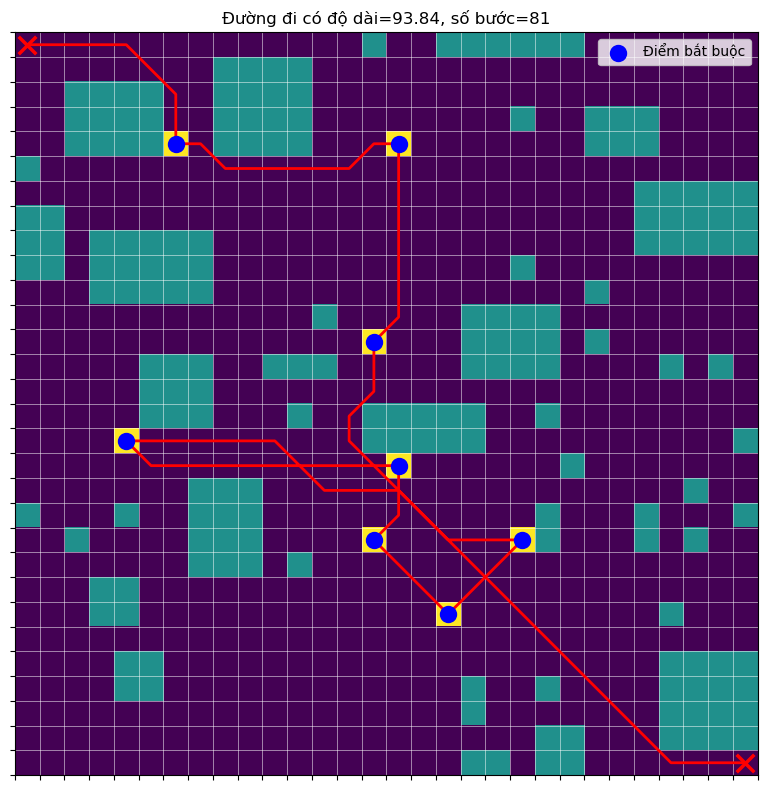

In [18]:
visualize_path(grid, path, mandatory_waypoints)